In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel(r'D:\Projects\delicious_food\delicious_food.xlsx')
print("形状:", df.shape)
print("\n前3行:\n", df.head(3))
print("\n列名:\n", df.columns.tolist())


形状: (10, 15)

前3行:
                      唯一标识        店铺ID            店铺名称          联系电话  店铺平均评分  \
0  M2QV2bobd2-w-3bPrfbfhQ  1000066880  Nice手游茶室（丽庭居店）  1.348022e+10     4.1   
1  V2hMfsyx-Umm0Dlzv2A-2w  1000117062           合众肠粉店  1.353988e+10     4.2   
2  RkCQh1N09lm0-V78gWOX5Q   100013138     久忆·锅巴湘（南村店）  1.801182e+10     4.4   

   人均消费  城市   区县            店铺地址 店铺所属商圈    WGS84纬度     WGS84经度  \
0     0  广州  白云区  白云区丽庭路丽庭居a栋15号  同和/京溪  23.199974  113.321550   
1     7  广州  荔湾区      荔湾区高基大街24号    康王路  23.123661  113.244903   
2     0  广州  番禺区     番禺区兴业大道163号  长隆/南村  22.994080  113.350328   

                 营业时间                     店铺评分细则  \
0  周一至周日\n12:00-02:00  口味: 4.2  环境: 4.0  服务: 4.1   
1                 NaN  口味: 4.3  环境: 4.2  服务: 4.1   
2  周一至周日\n09:30-21:30  口味: 4.3  环境: 4.3  服务: 4.6   

                                               设施和特色  
0                                                NaN  
1                                                NaN  
2  有包厢,免费停车,可电话预订,美团充电宝,

In [3]:
print("=== info ===")
df.info()
print("\n=== describe ===")
print(df.describe())


=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
唯一标识       10 non-null object
店铺ID       10 non-null int64
店铺名称       10 non-null object
联系电话       9 non-null float64
店铺平均评分     10 non-null float64
人均消费       10 non-null int64
城市         10 non-null object
区县         10 non-null object
店铺地址       10 non-null object
店铺所属商圈     10 non-null object
WGS84纬度    10 non-null float64
WGS84经度    10 non-null float64
营业时间       9 non-null object
店铺评分细则     10 non-null object
设施和特色      7 non-null object
dtypes: float64(4), int64(2), object(9)
memory usage: 1.2+ KB

=== describe ===
               店铺ID          联系电话     店铺平均评分       人均消费    WGS84纬度     WGS84经度
count  1.000000e+01  9.000000e+00  10.000000  10.000000  10.000000   10.000000
mean   9.102164e+08  1.608087e+10   4.170000  13.300000  23.215668  113.294878
std    2.846764e+08  2.529399e+09   0.326769  22.435339   0.155839    0.113295
min    1.000131e+08  1.328848e+10   3.60

In [4]:
# === 拆评分细则 ===
# 从 "口味: 4.2  环境: 4.0  服务: 4.1" 中提取数字
import re

def extract_score(text, label):
    if pd.isna(text):
        return None
    match = re.search(rf'{label}:\s*([\d.]+)', str(text))
    return float(match.group(1)) if match else None

df['口味评分'] = df['店铺评分细则'].apply(lambda x: extract_score(x, '口味'))
df['环境评分'] = df['店铺评分细则'].apply(lambda x: extract_score(x, '环境'))
df['服务评分'] = df['店铺评分细则'].apply(lambda x: extract_score(x, '服务'))

print("评分拆解完成")
print(df[['店铺名称', '店铺平均评分', '口味评分', '环境评分', '服务评分', '人均消费']].head(10))


评分拆解完成
               店铺名称  店铺平均评分  口味评分  环境评分  服务评分  人均消费
0    Nice手游茶室（丽庭居店）     4.1   4.2   4.0   4.1     0
1             合众肠粉店     4.2   4.3   4.2   4.1     7
2       久忆·锅巴湘（南村店）     4.4   4.3   4.3   4.6     0
3     苏咑柠（碧桂园1960店）     3.7   3.8   3.6   3.6    13
4  芒芒多·四元喝好茶（万民广场店）     4.1   4.2   4.1   4.0    10
5         本屋小串（花都店）     4.1   3.9   3.9   4.5     0
6     库迪咖啡（广州龙禧中心店）     4.5   4.6   4.6   4.3     8
7        缇里咖啡（美博城店）     4.4   4.4   4.8   4.1    21
8      ？？·那里·韩国辣鸡爪店     4.6   4.5   4.4   4.8    74
9     粤广烧劲脆烧肉（万松园店）     3.6   3.5   3.9   3.5     0


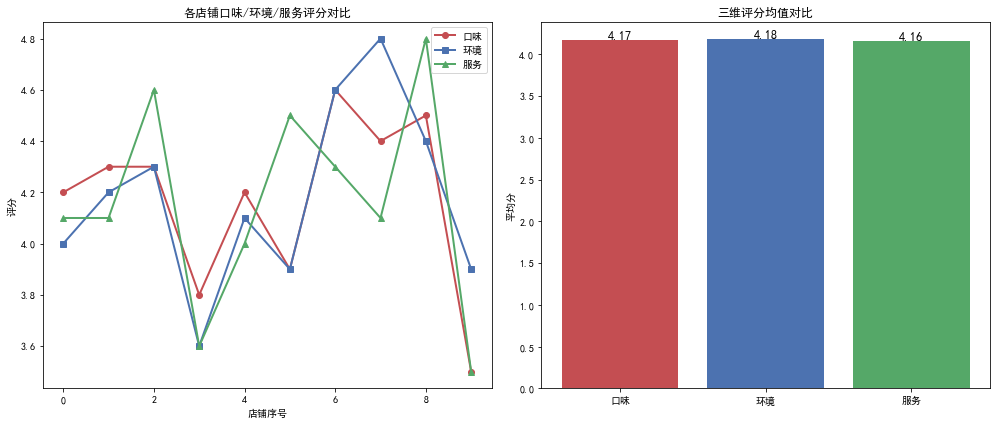

三维评分均值:
口味评分: 4.17
环境评分: 4.18
服务评分: 4.16


In [5]:
# === 三维评分对比 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：散点对比
score_cols = ['口味评分', '环境评分', '服务评分']
x = range(len(df))
axes[0].plot(x, df['口味评分'], 'o-', label='口味', color='#C44E52', linewidth=2)
axes[0].plot(x, df['环境评分'], 's-', label='环境', color='#4C72B0', linewidth=2)
axes[0].plot(x, df['服务评分'], '^-', label='服务', color='#55A868', linewidth=2)
axes[0].set_xlabel('店铺序号')
axes[0].set_ylabel('评分')
axes[0].set_title('各店铺口味/环境/服务评分对比')
axes[0].legend()

# 右：平均对比
means = [df['口味评分'].mean(), df['环境评分'].mean(), df['服务评分'].mean()]
axes[1].bar(['口味', '环境', '服务'], means, color=['#C44E52', '#4C72B0', '#55A868'])
axes[1].set_title('三维评分均值对比')
axes[1].set_ylabel('平均分')
for i, v in enumerate(means):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print("三维评分均值:")
for col in score_cols:
    print(f"{col}: {df[col].mean():.2f}")


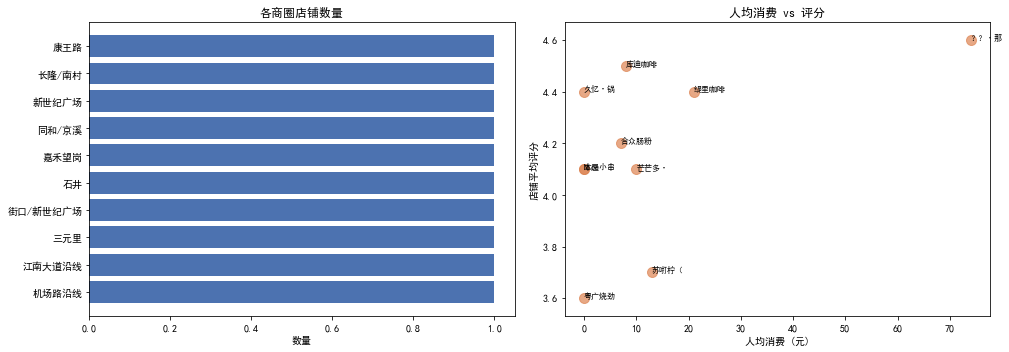

人均消费最高 TOP5:
               店铺名称  人均消费  店铺平均评分    店铺所属商圈
8      ？？·那里·韩国辣鸡爪店    74     4.6     机场路沿线
7        缇里咖啡（美博城店）    21     4.4       三元里
3     苏咑柠（碧桂园1960店）    13     3.7  街口/新世纪广场
4  芒芒多·四元喝好茶（万民广场店）    10     4.1        石井
6     库迪咖啡（广州龙禧中心店）     8     4.5      嘉禾望岗


In [6]:
# === 商圈分布 & 人均消费 ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：商圈分布
circles = df['店铺所属商圈'].value_counts()
axes[0].barh(circles.index, circles.values, color='#4C72B0')
axes[0].set_title('各商圈店铺数量')
axes[0].set_xlabel('数量')

# 右：人均消费 vs 评分
axes[1].scatter(df['人均消费'], df['店铺平均评分'], s=100, c='#DD8452', alpha=0.7)
axes[1].set_xlabel('人均消费 (元)')
axes[1].set_ylabel('店铺平均评分')
axes[1].set_title('人均消费 vs 评分')
for i, row in df.iterrows():
    axes[1].annotate(row['店铺名称'][:4], (row['人均消费'], row['店铺平均评分']), fontsize=8)

plt.tight_layout()
plt.show()

print("人均消费最高 TOP5:")
print(df.nlargest(5, '人均消费')[['店铺名称', '人均消费', '店铺平均评分', '店铺所属商圈']])


广州餐饮市场评分普遍较高，口味评分往往高于环境和服务评分——"好吃"仍然是核心竞争力。